In [ ]:
import csv
import pandas as pd
import matplotlib.pyplot as plt


def extract_report(filename, reporter_name):
   
   #Read the CSV file and extract the relevant rows
    with open(filename, "r", encoding="utf-8-sig", newline="") as file:
        rows = list(csv.reader(file))
   
   #Get the reuired rows for processing
    run_row = rows[6]
    parameter_row = rows[7]
    reporter_row = rows[8]
    final_row = rows[9]

    parameter_name = parameter_row[0].strip()

    records = []
    current_parameter = None
    current_run = None
    
    #Extract values for the selected reoprter
    for column in range(len(reporter_row)):

        if column < len(run_row) and run_row[column].strip() != "":
            try:
                current_run = int(float(run_row[column]))
            except ValueError:
                pass

        if column < len(parameter_row) and parameter_row[column].strip() != "":
            try:
                current_parameter = float(parameter_row[column])
            except ValueError:
                pass

        # Extract the selected reporter
        if reporter_row[column].strip() == reporter_name:

            value_text = final_row[column].strip()

            if (
                current_parameter is not None
                and current_run is not None
                and value_text != ""
            ):
                records.append({
                    "Run": current_run,
                    parameter_name: current_parameter,
                    "Value": float(value_text)
                })

    raw_data = pd.DataFrame(records)

    #Stop if no matching data is found
    if raw_data.empty:
        raise ValueError( f"No values were found for '{reporter_name}' in '{filename}'.")

    # Calculate Summary Statistics
    summary = (raw_data.groupby(parameter_name)["Value"].agg(["mean", "std", "count"]) .reset_index())

    #Calculate standard error and 95% confidence interval
    summary["standard_error"] = (summary["std"] / summary["count"] ** 0.5)
    summary["ci95"] = 1.96 * summary["standard_error"]

    return parameter_name, raw_data, summary

   p_relapse      mean       std  count  standard_error      ci95
0       0.00  2.284538  1.344862     10        0.425283  0.833554
1       0.02  4.294855  2.229597     10        0.705061  1.381919
2       0.05  3.704202  1.604553     10        0.507404  0.994512
3       0.10  6.831478  3.126076     10        0.988552  1.937562
4       0.20  6.403673  2.934325     10        0.927915  1.818713


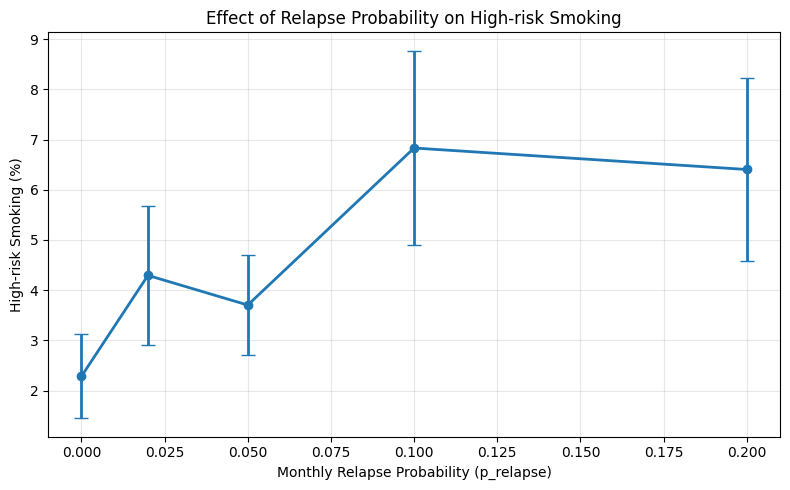

In [ ]:
#Effect of Relapse Probability on High-risk Smoking Analysis
parameter, raw_data, summary = extract_report("member3_prelapse_sweep.csv","report-pct-high-smoking")

print(summary)

plt.figure(figsize=(8, 5))

plt.errorbar(summary[parameter], summary["mean"],yerr=summary["ci95"],marker="o",linewidth=2,capsize=5)

plt.xlabel("Monthly Relapse Probability (p_relapse)")
plt.ylabel("High-risk Smoking (%)")
plt.title("Effect of Relapse Probability on High-risk Smoking")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig( "Figure_1_Relapse_Probability_High_Risk_Smoking.png", dpi=300, bbox_inches="tight")

plt.show()

   p_relapse  mean       std  count  standard_error      ci95
0       0.00  33.5  5.016639     10        1.586401  3.109345
1       0.02  36.6  5.929212     10        1.874981  3.674964
2       0.05  35.4  4.903513     10        1.550627  3.039229
3       0.10  34.6  6.801961     10        2.150969  4.215899
4       0.20  36.3  3.772709     10        1.193035  2.338349


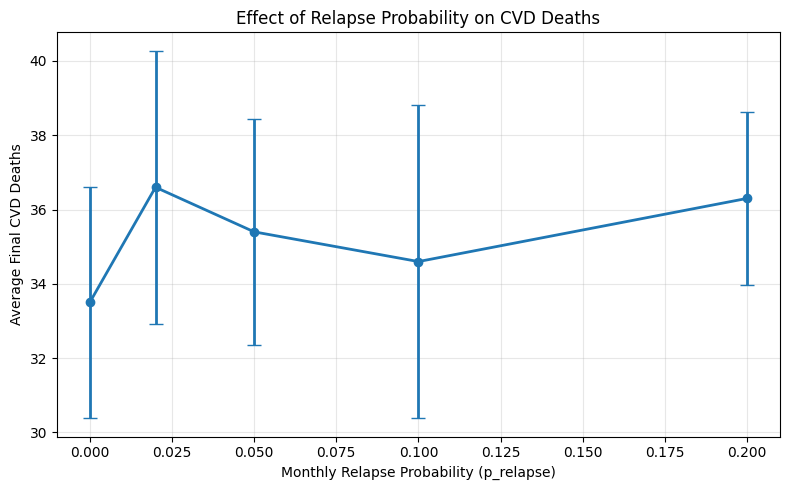

In [ ]:
#Effect of Relapse Probability on CVD Deaths Analysis
parameter, raw_data, summary = extract_report("member3_prelapse_sweep.csv","report-deaths")

print(summary)

plt.figure(figsize=(8, 5))
plt.errorbar(summary[parameter],summary["mean"],yerr=summary["ci95"], marker="o", linewidth=2, capsize=5)
plt.xlabel("Monthly Relapse Probability (p_relapse)")
plt.ylabel("Average Final CVD Deaths")
plt.title("Effect of Relapse Probability on CVD Deaths")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_2_Relapse_Probability_CVD_Deaths.png",dpi=300,bbox_inches="tight")

plt.show()

   t_lag_years  mean       std  count  standard_error      ci95
0          2.0  36.4  4.351245     10        1.375984  2.696930
1          5.0  35.1  6.402257     10        2.024571  3.968160
2         10.0  29.4  1.837873     10        0.581187  1.139126


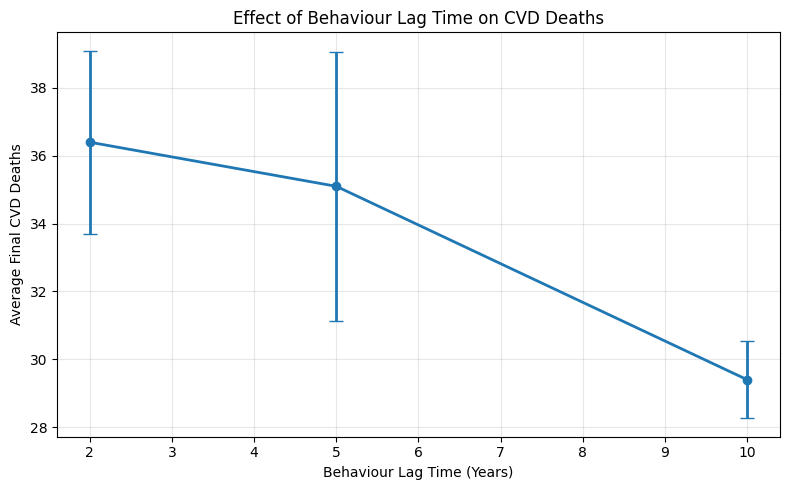

In [ ]:
#Effect of Behaviour Lag Time on CVD Deaths Analysis
parameter, raw_data, summary = extract_report("member3_tlag_sweep.csv","report-deaths")

print(summary)

plt.figure(figsize=(8, 5))
plt.errorbar(summary[parameter],summary["mean"],yerr=summary["ci95"],marker="o",linewidth=2,capsize=5)
plt.xlabel("Behaviour Lag Time (Years)")
plt.ylabel("Average Final CVD Deaths")
plt.title("Effect of Behaviour Lag Time on CVD Deaths")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_3_Behaviour_Lag_CVD_Deaths.png",dpi=300,bbox_inches="tight")

plt.show()

   omega_age      mean       std  count  standard_error      ci95
0       0.00  4.054155  0.105298     10        0.033298  0.065264
1       0.25  3.999061  0.004546     10        0.001438  0.002818
2       0.50  4.005672  0.004603     10        0.001455  0.002853
3       1.00  4.020040  0.009911     10        0.003134  0.006143


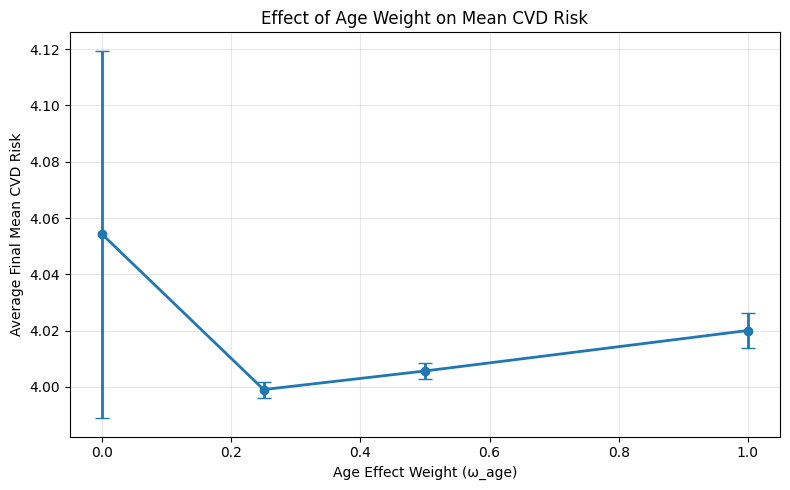

In [ ]:
#Effect of Age Weight on Mean CVD Risk Analysis
parameter, raw_data, summary = extract_report("member3_omega_sweep.csv","report-mean-risk")

print(summary)

plt.figure(figsize=(8, 5))
plt.errorbar(summary[parameter],summary["mean"],yerr=summary["ci95"],marker="o",linewidth=2,capsize=5)
plt.xlabel("Age Effect Weight (ω_age)")
plt.ylabel("Average Final Mean CVD Risk")
plt.title("Effect of Age Weight on Mean CVD Risk")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("Figure_4_Age_Weight_Mean_CVD_Risk.png",dpi=300,bbox_inches="tight")

plt.show()

   relapse_friend_threshold      mean       std  count  standard_error  \
0                      0.25  4.188377  0.171803     10        0.054329   
1                      0.50  4.033797  0.103201     10        0.032635   
2                      0.75  3.999966  0.111237     10        0.035176   
3                      1.00  4.029405  0.074868     10        0.023675   

       ci95  
0  0.106485  
1  0.063964  
2  0.068946  
3  0.046404  


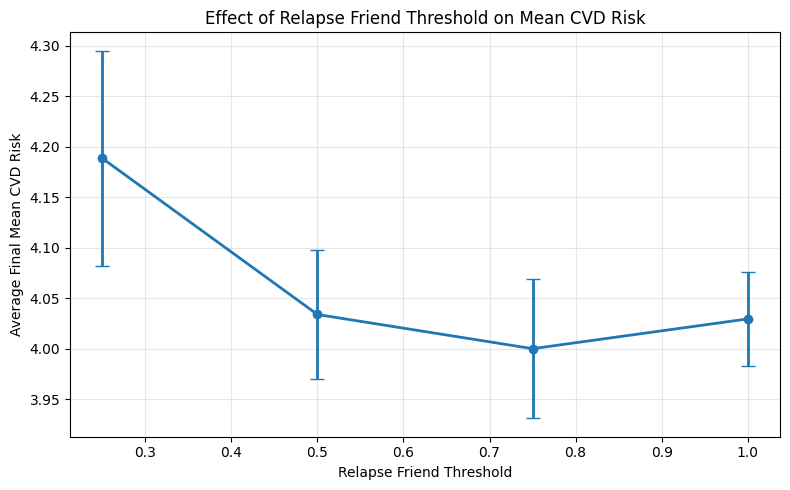

In [ ]:
#Effect of Relapse Friend Threshold on Mean CVD Risk Analysis
parameter, raw_data, summary = extract_report("member3_rft_sweep.csv","report-mean-risk")

print(summary)

plt.figure(figsize=(8, 5))
plt.errorbar(summary[parameter],summary["mean"],yerr=summary["ci95"],marker="o",linewidth=2,capsize=5)
plt.xlabel("Relapse Friend Threshold")
plt.ylabel("Average Final Mean CVD Risk")
plt.title("Effect of Relapse Friend Threshold on Mean CVD Risk")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig( "Figure_5_Relapse_Friend_Threshold_Mean_Risk.png",dpi=300,bbox_inches="tight")

plt.show()